# Introduction to Deep Learning with Tensorflow

# 0. Imports and Setup

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from pathlib import Path

# 1. Overview

Building a deep learning model requires the following steps:
- Handle data - `datasets`
- Build the architecture - `model`
- Train the model using gthe architecture and the model
- Validate the trained model

We will first use a simple tabular data classification to show the mechanics of model building

# 2. Build a simple model with Tabular Data

## Dataset

In [54]:
from sklearn.datasets import make_blobs, make_moons
from sklearn.model_selection import train_test_split
X, y = make_blobs(n_samples=5000, n_features=2, centers=4, cluster_std=1.5, random_state=88)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=88)

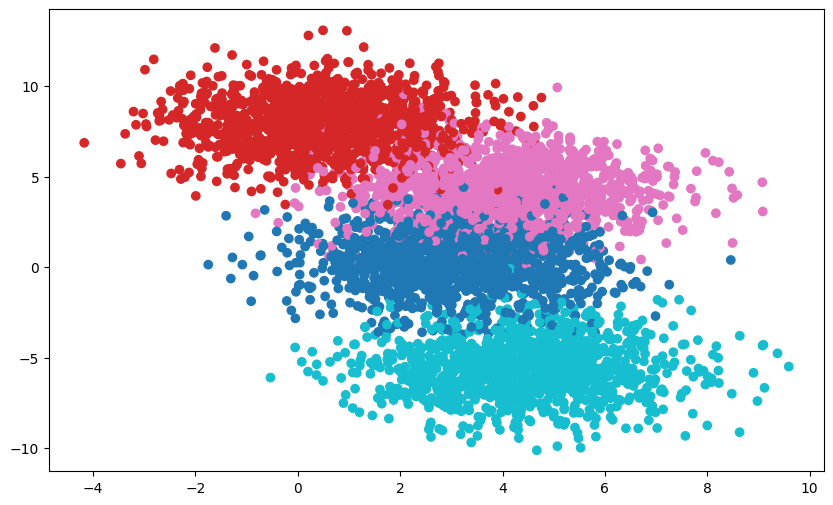

In [55]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='tab10');

Look at the 'shape' of the data

In [56]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((4000, 2), (4000,), (1000, 2), (1000,))

In [57]:
y_train[:5]

array([3, 3, 2, 1, 2])

Labels are integers (one for each of the 4 categories).

We need to convert this into one hot encoded values.

In [58]:
y_train_ohe =keras.utils.to_categorical(y_train, num_classes=4)
y_test_ohe = keras.utils.to_categorical(y_test, num_classes=4)
y_train_ohe.shape, y_test_ohe.shape

((4000, 4), (1000, 4))

In [59]:
y_train_ohe[:5]

array([[0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.]])

In [60]:
for i, ohe in zip(y_train[:5], y_test_ohe[:5]):
    print(f" - {i} -> {ohe}")

 - 3 -> [1. 0. 0. 0.]
 - 3 -> [0. 0. 1. 0.]
 - 2 -> [1. 0. 0. 0.]
 - 1 -> [0. 0. 0. 1.]
 - 2 -> [1. 0. 0. 0.]


## Architecture

We will build a small model that:
- input: takes the `X` as input (shape: many samples with 2 values each)
- outputs: gives 4 values (one for each class). Value between 0 and 1 and sum of values = 1

In [61]:
model = keras.Sequential(name='MLP')
model.add(keras.layers.Input(shape=(2,)))
model.add(keras.layers.Dense(8, activation='relu'))
model.add(keras.layers.Dense(4, activation='softmax'))
model.summary()

Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60 (240.00 B)

 Trainable params: 60 (240.00 B)

 Non-trainable params: 0 (0.00 B)

Then we need to provide to the model the "tools" to learn:
- an optimiser (algorithm it will use to gradually converge to the correct parameters)
    - the optimiser can be parametrised to perform better
    - most important value to set is the learning rate
- a loss function (a measure of how wrong the model's predictions are) which will be minimized
- metrics (measure of performances humans will track)

In [62]:
opt = keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Training

Now we are ready with training, using our training dataset (`X_train` and `y_train_ohe`)

In [63]:
history = model.fit(
    X_train, y_train_ohe,
    validation_split=0.2,
    epochs=25,
    batch_size=32
)

Epoch 1/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2543 - loss: 2.5274 - val_accuracy: 0.3988 - val_loss: 1.4837
Epoch 2/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5069 - loss: 1.3157 - val_accuracy: 0.7000 - val_loss: 0.9755
Epoch 3/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6829 - loss: 0.9431 - val_accuracy: 0.7075 - val_loss: 0.7383
Epoch 4/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7179 - loss: 0.7150 - val_accuracy: 0.7337 - val_loss: 0.5906
Epoch 5/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7549 - loss: 0.6062 - val_accuracy: 0.8138 - val_loss: 0.4940
Epoch 6/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8270 - loss: 0.5025 - val_accuracy: 0.8600 - val_loss: 0.4306
Epoch 7/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8607 - loss: 0.4292 - val_accuracy: 0.8763 - val_loss: 0.3876
Epoch 8/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8607 - loss: 0.3997 - val_accuracy: 0.

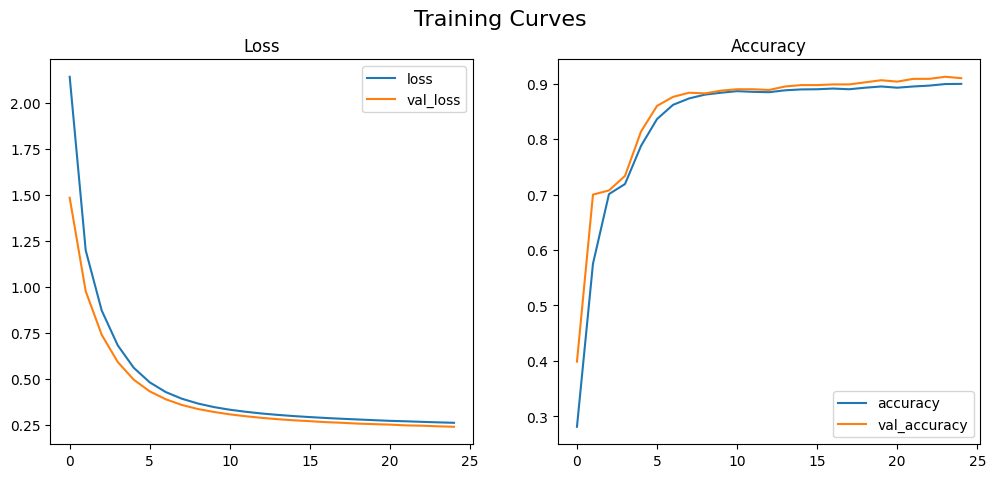

In [64]:
pd.DataFrame(history.history).columns
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(12,5))
pd.DataFrame(history.history).loc[:,['loss', 'val_loss']].plot(ax=ax1, title='Loss');  
pd.DataFrame(history.history).loc[:, ['accuracy', 'val_accuracy']].plot(ax=ax2, title='Accuracy');
fig.suptitle('Training Curves', fontsize=16);

## Evaluation 

Now we test the model with data that were not used for training: `X_test`, `y_test_ohe`

In [65]:
model.evaluate(X_test, y_test_ohe)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9026 - loss: 0.2538


[0.27136826515197754, 0.8880000114440918]

# Build another model with more complex tabular data

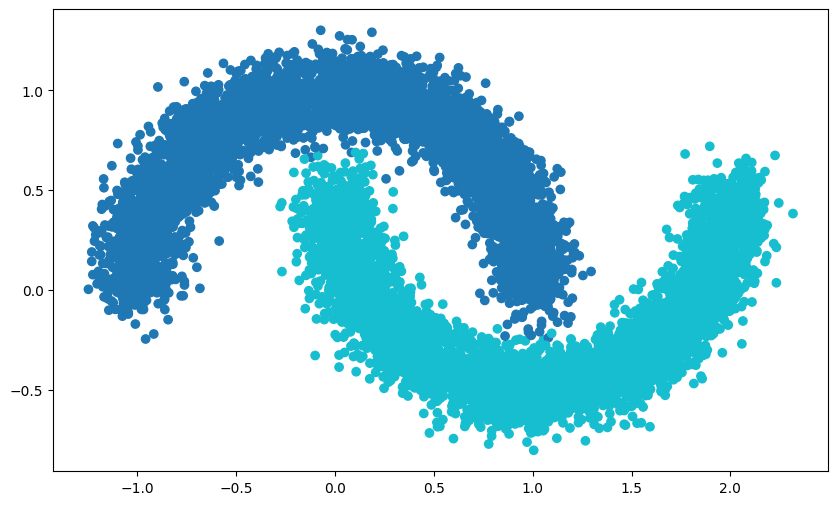

In [66]:
X, y = make_moons(n_samples=10_000, noise=0.1, random_state=88)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=88)
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='tab10');

In [67]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((8000, 2), (8000,), (2000, 2), (2000,))

In [68]:
y_train_ohe = keras.utils.to_categorical(y_train, num_classes=2)
y_test_ohe = keras.utils.to_categorical(y_test, num_classes=2)
y_train_ohe.shape, y_test_ohe.shape

((8000, 2), (2000, 2))

In [69]:
y_train_ohe[:5]

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.]])

In [70]:
model = keras.Sequential(name='MLP_2')
model.add(keras.layers.Input(shape=(2,)))
model.add(keras.layers.Dense(4, activation='relu'))
model.add(keras.layers.Dense(8, activation='relu'))
model.add(keras.layers.Dense(2, activation='softmax'))
model.summary()

Model: "MLP_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70 (280.00 B)

 Trainable params: 70 (280.00 B)

 Non-trainable params: 0 (0.00 B)

In [71]:
opt = keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [72]:
history = model.fit(
    X_train, y_train_ohe,
    validation_split=0.2,
    epochs=25,
    batch_size=32
)

Epoch 1/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5663 - loss: 0.6669 - val_accuracy: 0.7900 - val_loss: 0.4872
Epoch 2/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8049 - loss: 0.4400 - val_accuracy: 0.8406 - val_loss: 0.3387
Epoch 3/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8577 - loss: 0.3132 - val_accuracy: 0.8875 - val_loss: 0.2668
Epoch 4/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8932 - loss: 0.2558 - val_accuracy: 0.9062 - val_loss: 0.2213
Epoch 5/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9080 - loss: 0.2121 - val_accuracy: 0.9156 - val_loss: 0.1948
Epoch 6/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9188 - loss: 0.1844 - val_accuracy: 0.9244 - val_loss: 0.1745
Epoch 7/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9304 - loss: 0.1681 - val_accuracy: 0.9394 - val_loss: 0.1569
Epoch 8/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9379 - loss: 0.1533 - val_accuracy: 0.

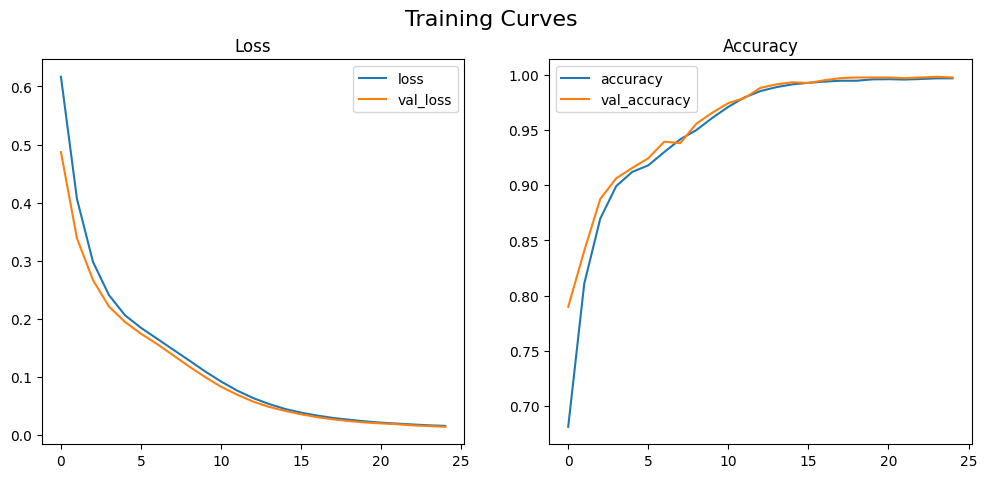

In [73]:
pd.DataFrame(history.history).columns
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(12,5))
pd.DataFrame(history.history).loc[:,['loss', 'val_loss']].plot(ax=ax1, title='Loss');  
pd.DataFrame(history.history).loc[:, ['accuracy', 'val_accuracy']].plot(ax=ax2, title='Accuracy');
fig.suptitle('Training Curves', fontsize=16);

# 3. Build a simple CNN

## Dataset

`datasets` gives access to specific datasets, such as:

Tabular:
- boston_housing
- california_housing

Computer Vision
- mnist
- fashion_mnist
- cifar10
- cifar100

NLP
- imdb
- reuters

In [76]:
from keras import datasets
(X_train, y_train), (X_test, y_test) = datasets.fashion_mnist.load_data()

In [77]:
X_train.shape

(60000, 28, 28)

### Exploring the dataset

Let's have look at some of the images

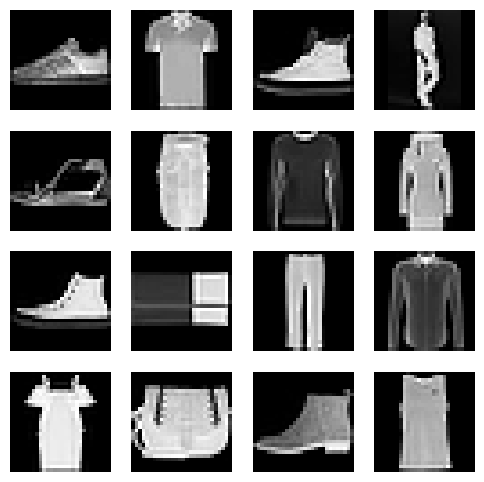

In [78]:
number_of_train_images = len(X_train)
number_of_train_images_to_show = 16
random_list_of_images_to_show = np.random.randint(0, number_of_train_images , number_of_train_images_to_show)

fig, axs = plt.subplots(4, 4, figsize=(6,6))
for i, ax in zip(random_list_of_images_to_show, axs.flatten()):
    ax.imshow(X_train[i], cmap='gray')
    ax.axis('off')
plt.show()

### Image intensity normalisation

Normalise the intensities:

In [81]:
X_test[0, 10:20, :10]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   1,   0,   2,   1],
       [  0,   0,   0,   0,   1,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   2,   4,   1,   0],
       [  0,   0,   2,   2,   1,   2,   0,   0,   0,   0],
       [  3,   0,   0,   0,   0,   0,   0,  21,  53,  92],
       [  0,   0,  23,  54,  65,  76,  85, 118, 128, 123],
       [  0,  68,  94,  90, 111, 114, 111, 114, 115, 127],
       [ 70, 169, 129, 104,  98, 100,  94,  97,  98, 102]], dtype=uint8)

In [82]:
X_train = X_train / 255.
X_test = X_test / 255.

In [83]:
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

We have 60,000 training images and 10,000 test images, each of size (28, 28)

But a Convolutional Neural Network models need to be fed with images whose last dimension is the number of channels `(NUMBER_OF_IMAGES, HEIGHT, WIDTH, CHANNELS)`

The images are grayscale images i.e. they only have one channel, this is why the shape the each image is (28,28) and not (28,28,1) as the last dimension is not useful in general  

But in this case, we need to add it explicitely

In [84]:
from tensorflow.keras.backend import expand_dims

X_train = expand_dims(X_train, axis=-1)
X_test = expand_dims(X_test, axis=-1)

X_train.shape, X_test.shape

(TensorShape([60000, 28, 28, 1]), TensorShape([10000, 28, 28, 1]))

### One Hot Encoding of Target/Class

In [85]:
y_train[:5]

array([9, 0, 0, 3, 0], dtype=uint8)

In [86]:
from tensorflow.keras.utils import to_categorical

y_train_ohe = to_categorical(y_train, num_classes=10)
y_test_ohe = to_categorical(y_test, num_classes=10)

In [87]:
y_train_ohe.shape, y_test_ohe.shape

((60000, 10), (10000, 10))

## Architecture

In [88]:
model = keras.Sequential(name="Fashion_MNIST_CNN")

model.add(keras.layers.Input(shape=(28, 28, 1), name='Input_Layer'))

### First Convolution & MaxPooling
model.add(keras.layers.Conv2D(8, (4,4), activation='relu', padding='same', name='L1_Conv'))
model.add(keras.layers.MaxPool2D(pool_size=(2,2)))

### Flattening
model.add(keras.layers.Flatten())

### One Fully Connected layer - "Fully Connected" is equivalent to saying "Dense"
model.add(keras.layers.Dense(10, activation='relu', name='L3_FC'))

### Last layer - Classification Layer with 10 outputs corresponding to 10 digits
model.add(keras.layers.Dense(10, activation='softmax', name='L4_Output'))

model.summary()

Model: "Fashion_MNIST_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1_Conv (Conv2D)                │ (None, 28, 28, 8)      │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L3_FC (Dense)                   │ (None, 10)             │        15,690 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L4_Output (Dense)               │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,936 (62.25 KB)

 Trainable params: 15,936 (62.25 KB)

 Non-trainable params: 0 (0.00 B)

In [89]:
### Model compilation
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam', 
    metrics=['accuracy']
)

## Training

In [90]:
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(patience = 5, restore_best_weights = True)

history = model.fit(X_train, 
                    y_train_ohe,
                    validation_split = 0.3,
                    batch_size = 32,
                    epochs = 25,
                    callbacks = [es],
                    verbose = 1
)


Epoch 1/25
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6904 - loss: 0.8784 - val_accuracy: 0.8378 - val_loss: 0.4774
Epoch 2/25
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8463 - loss: 0.4481 - val_accuracy: 0.8478 - val_loss: 0.4322
Epoch 3/25
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8628 - loss: 0.3920 - val_accuracy: 0.8654 - val_loss: 0.3830
Epoch 4/25
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8713 - loss: 0.3648 - val_accuracy: 0.8748 - val_loss: 0.3602
Epoch 5/25
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8792 - loss: 0.3454 - val_accuracy: 0.8737 - val_loss: 0.3631
Epoch 6/25
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8881 - loss: 0.3157 - val_accuracy: 0.8877 - val_loss: 0.3263
Epoch 7/25
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8931 - loss: 0.3036 - val_accuracy: 0.8911 - val_loss: 0.3142
Epoch 8/25
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8972 - loss: 0.2854 - 

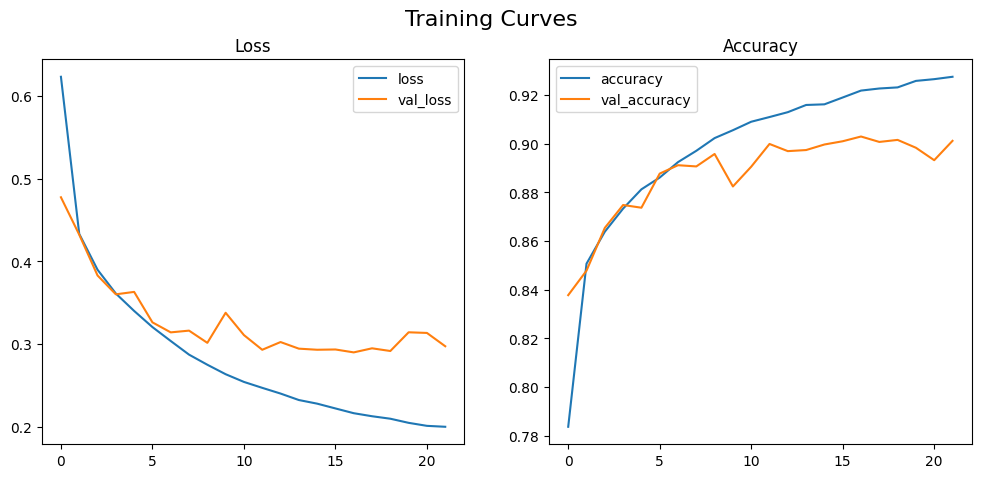

In [91]:
pd.DataFrame(history.history).columns
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(12,5))
pd.DataFrame(history.history).loc[:,['loss', 'val_loss']].plot(ax=ax1, title='Loss');  
pd.DataFrame(history.history).loc[:, ['accuracy', 'val_accuracy']].plot(ax=ax2, title='Accuracy');
fig.suptitle('Training Curves', fontsize=16);

## Example with color images

In [92]:
from keras import datasets
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

In [93]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((50000, 32, 32, 3), (50000, 1), (10000, 32, 32, 3), (10000, 1))

### Exploring the dataset

Let's have look at some of the images

In [94]:
cls_nb2cls_name = {
    0: 'airplane',
    1: 'automobile',
    2: 'bird',
    3: 'cat',
    4: 'deer',
    5: 'dog',
    6: 'frog',
    7: 'horse',
    8: 'ship',
    9: 'truck'
}

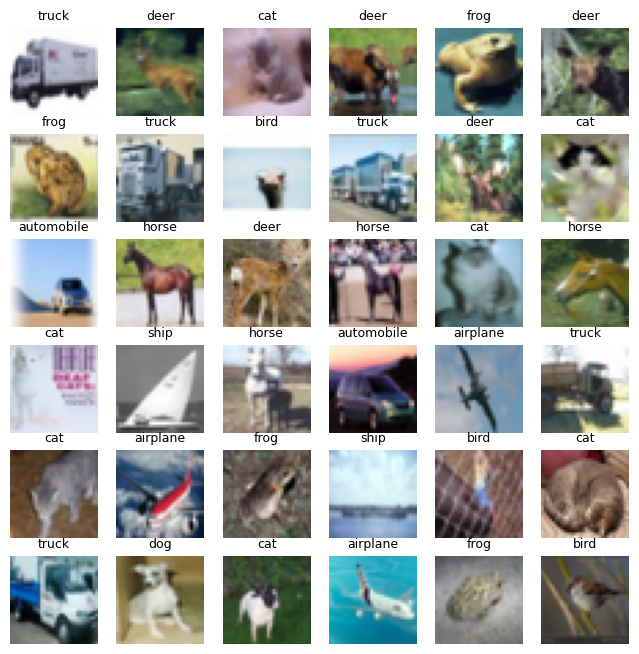

In [95]:
number_of_train_images = len(X_train)
number_of_train_images_to_show = 36
random_list_of_images_to_show = np.random.randint(0, number_of_train_images , number_of_train_images_to_show)

fig, axs = plt.subplots(6, 6, figsize=(8,8))
for i, ax in zip(random_list_of_images_to_show, axs.flatten()):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f"{cls_nb2cls_name[y_train[i][0]]}", fontsize=9)
    ax.axis('off')
plt.show()

### Image intensity normalisation

Let's check some intensity values for one color channel:

In [96]:
X_train[0, :5, :5, 0]

array([[ 59,  43,  50,  68,  98],
       [ 16,   0,  18,  51,  88],
       [ 25,  16,  49,  83, 110],
       [ 33,  38,  87, 106, 115],
       [ 50,  59, 102, 127, 124]], dtype=uint8)

The image in in uint8, we need to normalise the intensities to float between 0 and 1.

In [97]:
X_train = X_train / 255.
X_test = X_test / 255.

In [98]:
X_train[0, :5, :5, 0]

array([[0.23137255, 0.16862745, 0.19607843, 0.26666667, 0.38431373],
       [0.0627451 , 0.        , 0.07058824, 0.2       , 0.34509804],
       [0.09803922, 0.0627451 , 0.19215686, 0.3254902 , 0.43137255],
       [0.12941176, 0.14901961, 0.34117647, 0.41568627, 0.45098039],
       [0.19607843, 0.23137255, 0.4       , 0.49803922, 0.48627451]])

### One Hot Encoding of Target/Class

In [99]:
from tensorflow.keras.utils import to_categorical

y_train_ohe = to_categorical(y_train, num_classes=10)
y_test_ohe = to_categorical(y_test, num_classes=10)

In [100]:
y_train_ohe.shape, y_test_ohe.shape

((50000, 10), (10000, 10))

## Architecture

In [101]:
model = keras.Sequential(name="MNIST_CNN")

model.add(keras.layers.Input(shape=(32, 32, 3), name='Input_Layer'))

### First Convolution & MaxPooling
model.add(keras.layers.Conv2D(8, (5,5), activation='relu', padding='same', name='L1_Conv'))
model.add(keras.layers.MaxPool2D(pool_size=(2,2)))

### Second Convolution & MaxPooling
model.add(keras.layers.Conv2D(16, (4,4), activation='relu', padding='same', name='L2_Conv'))
model.add(keras.layers.MaxPool2D(pool_size=(2,2)))

### Third Convolution & MaxPooling
model.add(keras.layers.Conv2D(32, (3,3), activation='relu', padding='same', name='L3_Conv'))
model.add(keras.layers.MaxPool2D(pool_size=(2,2)))

### Flattening
model.add(keras.layers.Flatten())

### One Fully Connected layer - "Fully Connected" is equivalent to saying "Dense"
model.add(keras.layers.Dense(10, activation='relu', name='L3_FC'))

### Last layer - Classification Layer with 10 outputs corresponding to 10 digits
model.add(keras.layers.Dense(10, activation='softmax', name='L4_Output'))

model.summary()

Model: "MNIST_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1_Conv (Conv2D)                │ (None, 32, 32, 8)      │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2_Conv (Conv2D)                │ (None, 16, 16, 16)     │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L3_Conv (Conv2D)                │ (None, 8, 8, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L3_FC (Dense)                   │ (None, 10)             │         5,130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L4_Output (Dense)               │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,552 (49.03 KB)

 Trainable params: 12,552 (49.03 KB)

 Non-trainable params: 0 (0.00 B)

In [102]:
### Model compilation
opt = keras.optimizers.Adam(learning_rate=0.001)
model.compile(
    optimizer=opt,   # we also could use optimizer='adam', but then we cannot control the learning rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Training

In [103]:
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(patience = 5, restore_best_weights = True)

history = model.fit(X_train, 
                    y_train_ohe,
                    validation_split = 0.3,
                    batch_size = 32,
                    epochs = 50,
                    callbacks = [es],
                    verbose = 1
)


Epoch 1/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.1898 - loss: 2.1225 - val_accuracy: 0.4075 - val_loss: 1.6370
Epoch 2/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4226 - loss: 1.5806 - val_accuracy: 0.4522 - val_loss: 1.4981
Epoch 3/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4657 - loss: 1.4505 - val_accuracy: 0.4835 - val_loss: 1.4211
Epoch 4/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4930 - loss: 1.3763 - val_accuracy: 0.5165 - val_loss: 1.3407
Epoch 5/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5210 - loss: 1.3044 - val_accuracy: 0.5228 - val_loss: 1.3042
Epoch 6/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5407 - loss: 1.2573 - val_accuracy: 0.5348 - val_loss: 1.2752
Epoch 7/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5589 - loss: 1.2059 - val_accuracy: 0.5320 - val_loss: 1.2860
Epoch 8/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5676 - loss: 1.1897 - 

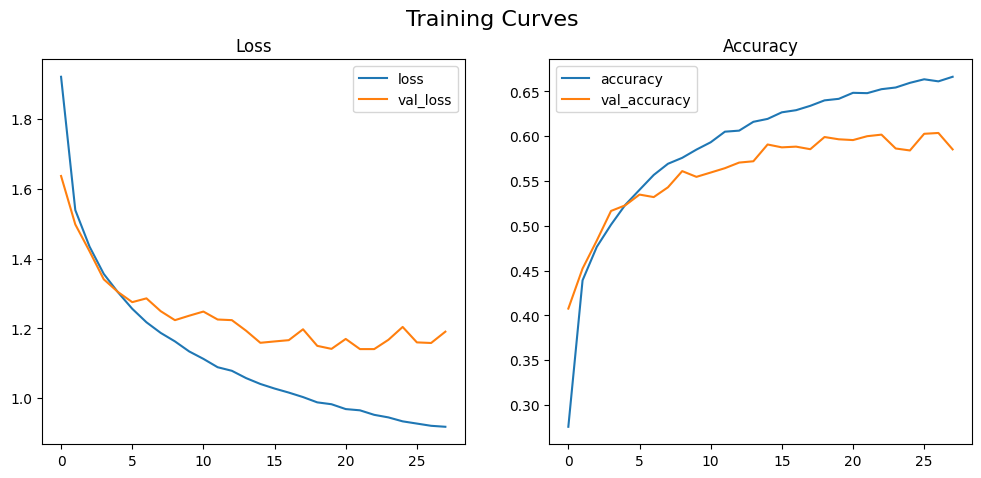

In [105]:
pd.DataFrame(history.history).columns
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(12,5))
pd.DataFrame(history.history).loc[:,['loss', 'val_loss']].plot(ax=ax1, title='Loss');  
pd.DataFrame(history.history).loc[:, ['accuracy', 'val_accuracy']].plot(ax=ax2, title='Accuracy');
fig.suptitle('Training Curves', fontsize=16);

In [106]:
model.evaluate(X_test, y_test_ohe)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6065 - loss: 1.1271


[1.141672134399414, 0.6022999882698059]